In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_curve,auc)

In [5]:
data=load_breast_cancer()
x=data.data
y=data.target
print("Dataset Shape:",x.shape)
print("Classes:",np.unique(y))


Dataset Shape: (569, 30)
Classes: [0 1]


In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [10]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [12]:
mle_model=LogisticRegression(penalty=None,max_iter=5000,random_state=42)
mle_model.fit(x_train,y_train)
y_pred_mle=mle_model.predict(x_test)

In [20]:
map_l2=LogisticRegression(penalty='l2',C=1.0,solver='lbfgs',max_iter=5000,random_state=42)
map_l2.fit(x_train,y_train)
y_pred_l2=map_l2.predict(x_test)

In [22]:
map_l1=LogisticRegression(penalty='l1',C=1.0,solver='liblinear',max_iter=5000,random_state=42)
map_l1.fit(x_train,y_train)
y_pred_l1=map_l1.predict(x_test)

In [24]:
def evaluate(model_name,y_true,y_pred):
    print("\n", "="*40)
    print(model_name)
    print("="*40)
    print("Accuracy:",accuracy_score(y_true,y_pred))
    print("Precision:",precision_score(y_true,y_pred))
    print("Recall:",recall_score(y_true,y_pred))
    print("F1 Score:",f1_score(y_true,y_pred))
    print("\nConfusion Matrix")
    print(confusion_matrix(y_true,y_pred))

In [25]:
evaluate("MLE",y_test,y_pred_mle)
evaluate("MAP(L2)",y_test,y_pred_l2)
evaluate("MAP(L1)",y_test,y_pred_l1)


MLE
Accuracy: 0.9210526315789473
Precision: 0.9701492537313433
Recall: 0.9027777777777778
F1 Score: 0.935251798561151

Confusion Matrix
[[40  2]
 [ 7 65]]

MAP(L2)
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112

Confusion Matrix
[[41  1]
 [ 1 71]]

MAP(L1)
Accuracy: 0.9912280701754386
Precision: 0.9863013698630136
Recall: 1.0
F1 Score: 0.993103448275862

Confusion Matrix
[[41  1]
 [ 0 72]]


In [28]:
print("Number of Zero Coefficients")
print("MLE :",np.sum(mle_model.coef_[0]==0))
print("MAP L2 :",np.sum(map_l2.coef_[0]==0))
print("MAP L1 :",np.sum(map_l1.coef_[0]==0))


Number of Zero Coefficients
MLE : 0
MAP L2 : 0
MAP L1 : 14


In [29]:
results=pd.DataFrame(columns=["Model","Accuracy","Precision","Recall","F1 Score"])
models=[("MLE",mle_model,y_pred_mle),
        ("MAP L2",map_l2,y_pred_l2),
        ("MAP L1",map_l1,y_pred_l1)]
for name,model,pred in models:
    results.loc[len(results)]=[
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ]
print(results)

    Model  Accuracy  Precision    Recall  F1 Score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


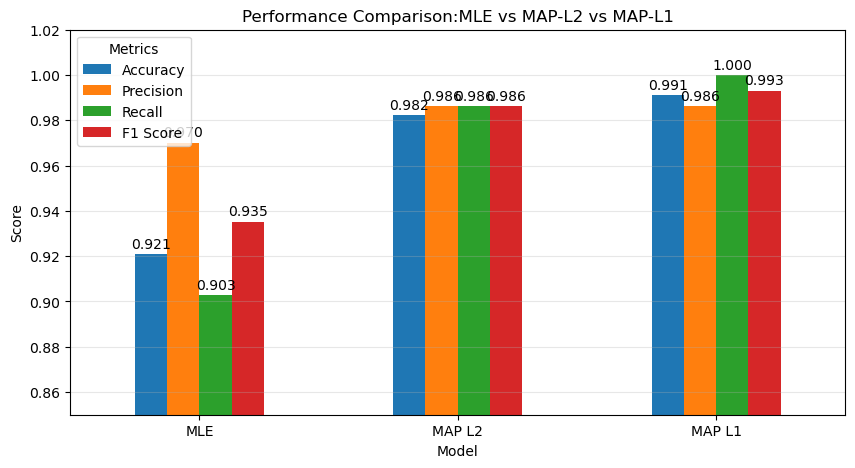

In [33]:
ax=results.set_index("Model").plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Performance Comparison:MLE vs MAP-L2 vs MAP-L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)

plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.grid(axis="y",alpha=0.3)
for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=2)

plt.show()

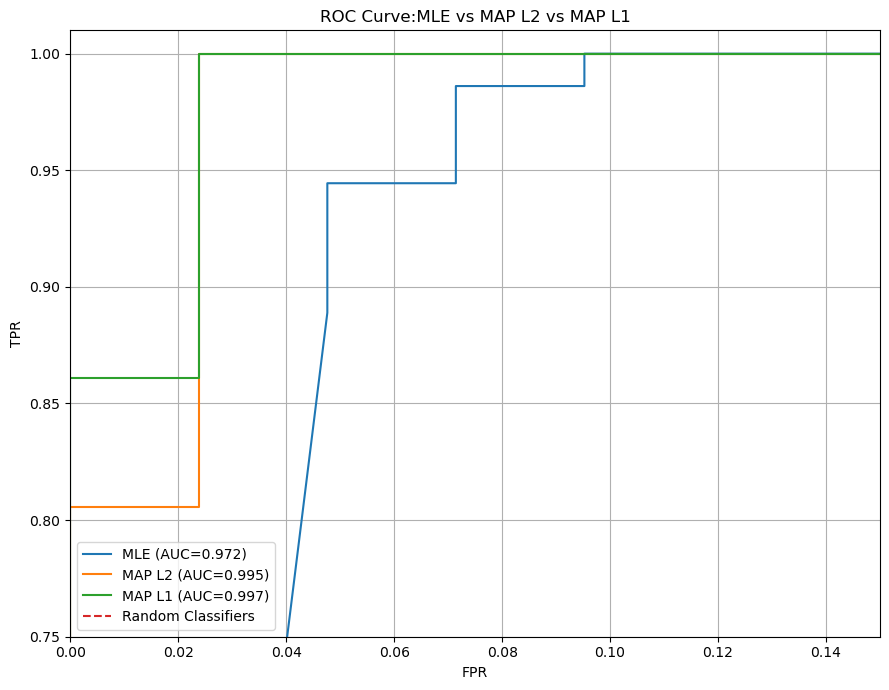

In [36]:
plt.figure(figsize=(9,7))
for name,model,pred in models:
    y_prob=model.predict_proba(x_test)[:,1]
    fpr,tpr,thresholds=roc_curve(y_test,y_prob)
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"{name} (AUC={roc_auc:.3f})"
    )
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifiers"
)
#plt.xlim(0,0.15)
#plt.ylim(0.75,1.01)

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve:MLE vs MAP L2 vs MAP L1")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()